Generating linelist file...
Calculating cross-section


(4000.0, 4200.0)

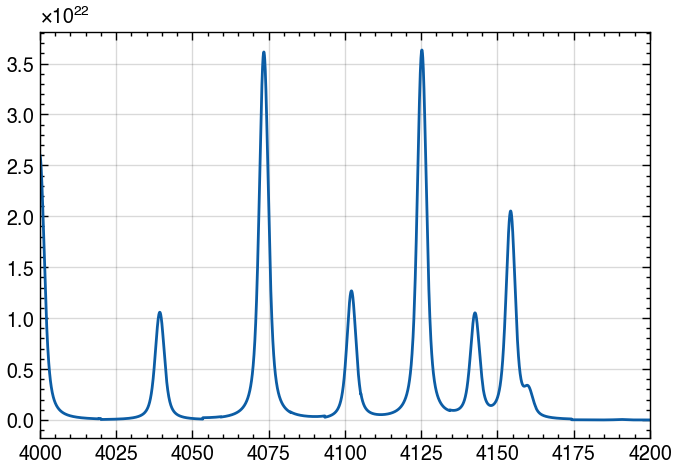

In [3]:
from ramlab.molecules.H2 import H2
import matplotlib.pyplot as plt
import wedme
import numpy as np
from ramlab.molecules.calculated_linelist_molecule import CalculatedLinelistMolecule
from ramlab.molecules.polarisation import Polarisation
from ramlab.simulate import simulate
import pickle as pkl

M = CalculatedLinelistMolecule(H2)

# Select the 5000 most intense transitions
transitions = M.get_all_transitions(laser_wavelength=532.6e-9, force_recalculate=True)
# transitions = transitions.sortby("crosssection", ascending=False)#[:5000] 

transitions = transitions[transitions.dv == 1]
# transitions = transitions[transitions.dJ == 0]

# Calculate the intensity of the transitions for T=860 K
I_stick = M.get_intensity(transitions, T=3000, polarisation=Polarisation.PERPENDICULAR)
dnu_stick = transitions.vacuum_wavenumber

# Simulate the spectrum with Gaussian and Lorentzian broadening
dnu_sim = np.linspace(dnu_stick.min(), dnu_stick.max()+200, 100000)
# dnu_sim = np.linspace(3800, 4200, 1000)
I_sim = simulate(dnu_sim, dnu_stick, I_stick, 1, 1)

wedme.dev()
plt.figure()
plt.plot(dnu_sim, I_sim)
plt.xlim(4000, 4200)

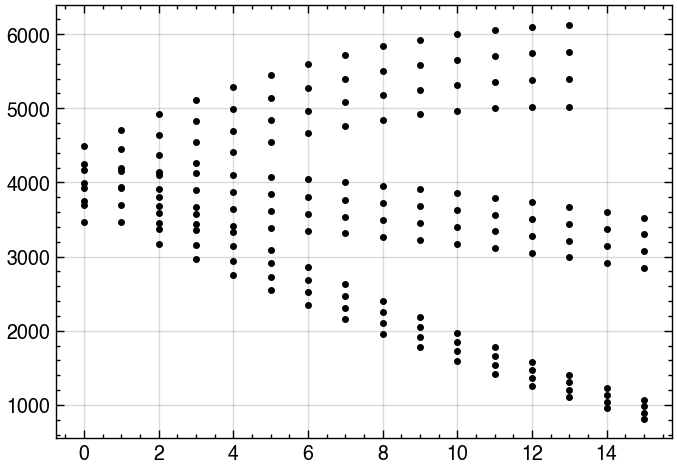

In [4]:
plt.figure()
plt.plot(transitions.initial_J, transitions.dE, 'k.')

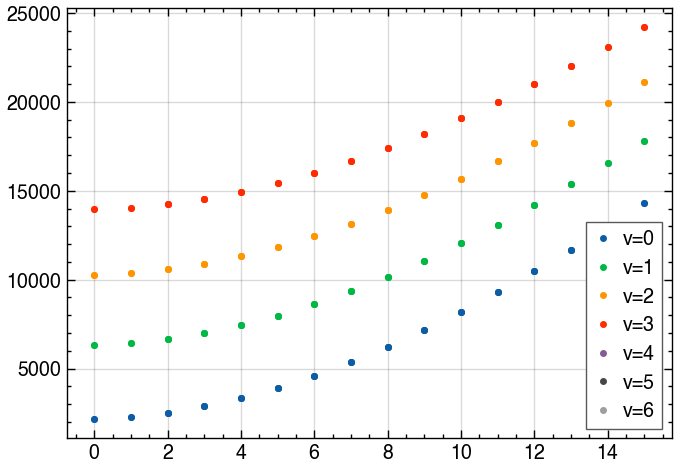

In [5]:
plt.figure()

for v in [0, 1, 2, 3, 4, 5, 6]:
    idx = transitions.initial_v == v
    plt.plot(transitions.state_initial.J[idx], transitions.state_initial.E[idx], '.', label=f"v={v}")

plt.legend()
plt.show()

Calculating cross-section
Calculating cross-section
Calculating cross-section


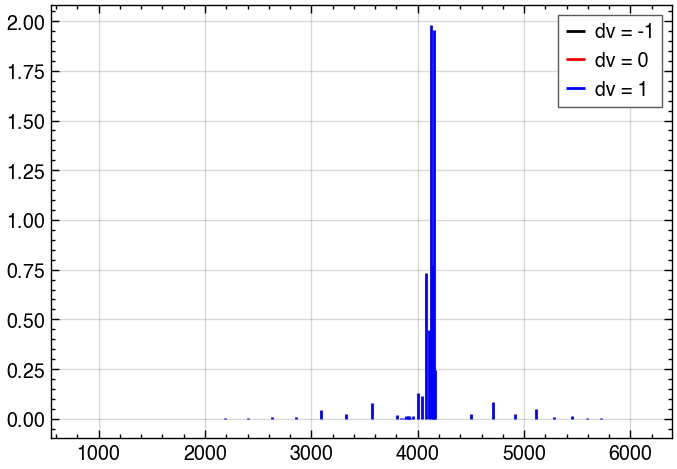

In [6]:
plt.figure()

# for i, dJ in enumerate([-2, 0, 2]):
for i, dv in enumerate([-1, 0, 1]):
    transitions_i = transitions[transitions.final_v - transitions.initial_v == dv]

    I_stick_i = M.get_intensity(transitions_i, T=1000)
    dnu_stick_i = transitions_i.vacuum_wavenumber

    plt.vlines(dnu_stick_i, 0, I_stick_i / np.nanmax(I_stick), color=["k", "r", "b"][i], label=f"dv = {dv}")

    # plt.vlines(dnu_stick_i, 0, I_stick_i / np.nanmax(I_stick), color=["k", "r", "b"][i], label=f"dJ = {dJ}")
plt.legend()
plt.show()

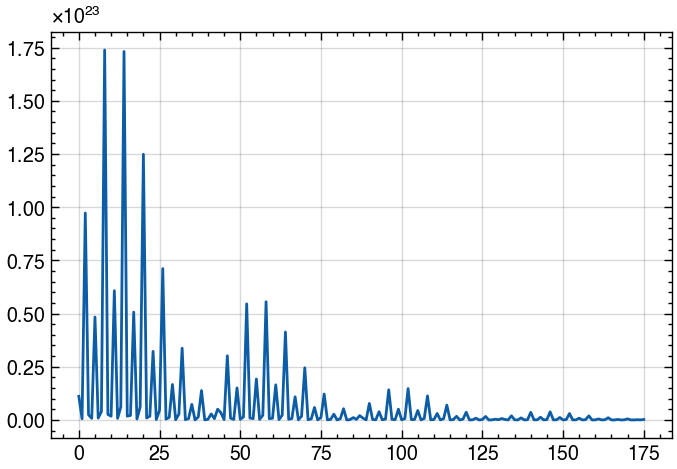

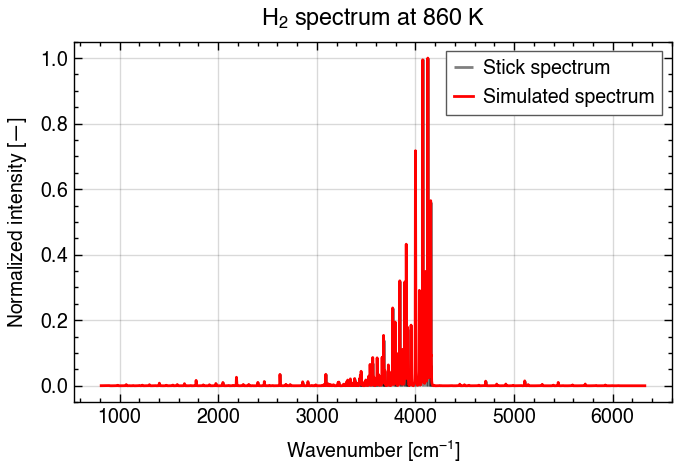

In [7]:
plt.figure()
plt.plot(I_stick)

# Plot the results
plt.figure()
plt.vlines(dnu_stick, 0, I_stick / np.nanmax(I_stick), color="k", alpha=0.5, label="Stick spectrum")
plt.plot(dnu_sim, I_sim / np.nanmax(I_sim), color="r", label="Simulated spectrum")
plt.legend()
plt.xlabel(r"Wavenumber [$\mathrm{cm^{-1}}$]")
plt.ylabel(r"Normalized intensity [$\mathrm{\emdash}$]")
plt.title(r"$\mathregular{H_2}$ spectrum at 860 K")
plt.show()

(0.0, 1.05)

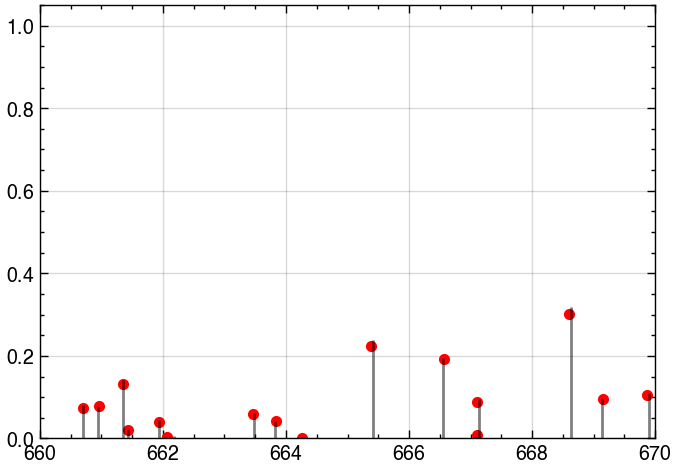

In [8]:
# I_stick = M.get_intensity(transitions, T=3000, polarisation=Polarisation.PERPENDICULAR)
import pickle as pkl
import numpy as np

dnu_scat = 1/532e-9 - dnu_stick*1e2
lambda_stick = 1e9/dnu_scat

with open('/Users/martijn/Library/CloudStorage/OneDrive-MaastrichtUniversity/Data/2d_rovib_noneq.pkl', 'rb') as f:
    h2 = pkl.load(f)
h2_old_lambda = h2['lambda']
h2_old_T = h2['Tr']
h2_old_I = h2['intensity'][np.eye(h2_old_T.size, dtype=np.bool)]

idx_Ti = np.argmin(np.abs(h2_old_T - 3000))


plt.figure()
plt.plot(h2_old_lambda, h2_old_I[idx_Ti] / np.nanmax(h2_old_I[idx_Ti])/0.83, "ro", label="Old simulated spectrum")
plt.vlines(lambda_stick, 0, I_stick / np.nanmax(I_stick), color="k", alpha=0.5, label="Stick spectrum")
# plt.vlines(h2_old_lambda, 0, h2_old_I[idx_Ti] / np.nanmax(h2_old_I[idx_Ti]), color="r", alpha=0.5, label="Simulated spectrum")
plt.xlim(660, 670)
# plt.xlim(620, 690)
plt.ylim(0, 1.05)